# 06 -- The final transfer function

This workbook reads every product a site has -- workbook 03's reference kinds at both rates and every
selection of hours a 10 Hz pass ran on, and workbook 05's forms -- applies one rule to all of them, and
delivers one EDI per site.

The rule is the survey's own statement of what a sound transfer function looks like, and it is stated with
its values before anything is chosen. A row is an earth where its phase sits in its quadrant, its apparent
resistivity curve is continuous, its short-end slope is inside the bound on the band the record actually
carries, the slope of its impedance is above the cut that separates an earth from an electric field
following dB/dt, its error bar is under the ceiling, and it holds at at least one period. The bar always
sits beside the shape call, because the shape rule alone passes on noise.

The product of record per component is then a choice between the site's own products: among the earths that
agree with a product of another reference kind, the one with the smallest bar. Corroboration comes from
another kind because two references that share no magnetics cannot carry the same noise into the estimate.
A component with no agreeing earth has no product of record, and that is a result rather than a gap: it
says the record does not support a delivered row there, and the file says so where a reader will see it.

The release and any earlier processing are never the arbiter of the choice. They are a shape check,
reported beside it in section 7 and last.

Six checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported FAILED and is
not revised afterwards.

| word | what it is | code key |
|---|---|---|
| single station | the site's own H and E | `single` |
| remote site | one other site's H as the reference | `remote` |
| fleet stack | a coherence-weighted mean of several sites' H | `stack` |
| observatory | an INTERMAGNET one-second record as the reference | `obs` |
| stack + observatory | the stack with the observatory as a member | `stack_obs` |

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase1"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
SITES = "all"                 # "all" | "largest" (the register's largest group) | a group name | ["Q49"]
RUNS = "all"                  # "all" = every run folder of the site | "latest" | ["first", "short10"]
RECORD_RATES = [1]            # the delivery rate the product of record is chosen among; [1, 10] admits a
                              # 10 Hz product as a whole row, which stops near 1,200 s at this survey
HALVES = True                 # True runs the two half passes over each candidate; False reads the ones on
                              # disk and leaves the reading UNJUDGED where there are none
LANES = 3                     # concurrent single-site subprocesses for the half passes, as in workbook 03
TIPPER_FROM = "xy"            # "xy" | "yx" | a reference kind: which product the tipper is taken from
COMPARE = "all"               # "all" | a list of the survey.yaml source names | "none" draws no comparison
RESAMPLE = False              # True writes final/<site>_resampled.edi on the ten-per-decade grid as well
PER_PAGE = 6                  # sites a gallery page
SHOW = None                   # None = the first site with a final; a site name shows that site's page
WORK_ROOT = None              # None = survey.yaml work_root; every file this workbook writes lands under it


In [2]:
# ---- the earth rule: a change here changes which products are earths and which is the record ----
QUALITY_BAND = (10, 1000)     # the band the shape, the bar and the choice are read over, in s
SLOPE_TOL = 1.2               # |d log rho / d log T| over the survey's live short band, at most this
AGREE_RHO = 0.20              # two products agree within this fraction in apparent resistivity
AGREE_PHASE = 5.0             # ... and this many degrees in phase
AGREE_BAND = (5, 200)         # ... over this band, in s
Z_SLOPE_CUT = -0.75           # d log|Z| / d log T below this is an inductive loop, not an earth
BAR_MAX = 1.0                 # the median relative error of |Z| over QUALITY_BAND, at most this

# ---- the splice: a change here changes which 10 Hz rows are delivered ----
SPLICE_JOIN_S = 16            # the period the 10 Hz row joins the 1 Hz row at, in s
SPLICE_MAX_STEP_PCT = 2.0     # the step at the join, in per cent, on the worse of the two ruled bands
SPLICE_GUARD = (18, 36)       # measured and printed per row and scored by nothing, in s
SHORT_FLOOR_S = 0.6           # nothing below this is delivered, in s
CONTROL_BAR_BAND = (2, 16)    # the band a 10 Hz selection is read against its random control over, in s
CONTROL_MARGIN = 0.20         # ... and the fraction of the control bar a selection must beat it by

PERIOD_RANGE = (0.3, 50000)   # the periods drawn and scored, in s
BANDS = [(5, 10), (10, 100), (100, 1000), (1000, 10000)]   # the decades every table reports, in s
COMPARE_BAND = (100, 1000)    # the band the comparison table reports, in s


## The products this workbook reads

Everything below reads `<work_root>/survey/runs.csv` and the run folders `<site>/<run>_<stamp>/`. `RUNS`
`"all"` keeps every run folder of every chosen site, which is what this workbook wants: the 1 Hz kinds, the
10 Hz passes and workbook 05's forms are all products of the same record and are all scored by the same rule.

A product carries three labels beside its site: the reference kind, the selection of hours it was estimated
on, and the form where workbook 05 made it. The 1 Hz pass runs on the whole record and its files carry no
selection tag; the 10 Hz pass runs on the most coherent hours by 1-30 s E-H coherence and never on the whole
record, so its files carry one: `f05`, `f10` and `f25` are the best 5, 10 and 25 per cent of hours and `r25`
is the random 25 per cent that controls them. A whole-record 10 Hz product, where a run folder holds one, is
a control and is read as `whole`.

In [3]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "3")

import sys
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

# mt_metadata logs a warning per channel while an EDI is read, and this workbook reads several hundred
from loguru import logger as _loguru
_loguru.remove()

import auslamp_proc
from auslamp_proc import agreement as AG, final as FN, halves as HV, products as PR
from auslamp_proc import readings as RD, splice as SP, survey as SV
from auslamp_proc.process import KIND_WORD
from auslamp_proc.site import deliver as DL
from auslamp_proc.figures import final as FIG

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 700)

T0 = time.time()
REPO = Path(auslamp_proc.__file__).resolve().parent.parent
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
OUT = WORK / "survey"
OUT.mkdir(parents=True, exist_ok=True)
WRITTEN = []

ASKED, WHY = SV.select_sites(sv, SITES, 0)
PROD = RD.all_products(sv, ASKED, runs=RUNS)
CHOSEN = [s for s in ASKED if s in set(PROD.site)]
NO_PRODUCT = [s for s in ASKED if s not in set(PROD.site)]
LIVE = RD.live_band(sv)
SHORT_BAND = RD.slope_band(LIVE)

def _dec(cell):
    try:
        return float(str(cell).strip())
    except ValueError:
        return None

DECLINATION = {r.site: _dec(r.declination_deg) for r in sv.sites.itertuples()}
DECLINATION = {k: v for k, v in DECLINATION.items() if v is not None and np.isfinite(v)}

_tfs = {}
def read(path):
    """One TFData per file: the readings, the agreement, the splice and four figures ask for the same file."""
    path = str(path)
    if path not in _tfs:
        _tfs[path] = PR.read_tf(path)
    return _tfs[path]

def final_dir(site):
    return WORK / str(site) / "final"

print("survey       %s" % sv.cfg["name"])
print("work root    %s" % WORK)
print("sites        %d of %d asked for carry a product (%s)" % (len(CHOSEN), len(ASKED), WHY))
print("             %s" % " ".join(CHOSEN))
if NO_PRODUCT:
    print("no product   %s -- run workbook 03 over them" % " ".join(NO_PRODUCT))
print("products     %d rows, %d on disk, over %d run folder(s)"
      % (len(PROD), int(PROD.on_disk.sum()), PROD.groupby(["run", "stamp"]).ngroups))
for (run, stamp), g in PROD.groupby(["run", "stamp"]):
    print("run          %-9s %-14s %3d product(s) at %s Hz over %2d site(s); selections %s"
          % (run, stamp, len(g), ", ".join("%g" % r for r in sorted(set(g.rate_hz))), g.site.nunique(),
             ", ".join(sorted(set(g.selection)))))
print("forms        %d product(s) workbook 05 left" % int((PROD.form != "").sum()))
print("live band    %s, from survey.yaml" % ("%g-%g s" % LIVE if LIVE else "not declared"))
print("short clause the 2-20 s slope clause is scored on %s"
      % ("%g-%g s" % SHORT_BAND if SHORT_BAND else "nothing: the live band leaves none of 2-20 s"))
print("delivery     the product of record is chosen among the %s Hz products"
      % ", ".join(str(r) for r in RECORD_RATES))
print("engine       auslamp_proc %s" % auslamp_proc.__version__)


survey       queensland_phase1
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1
sites        23 of 23 asked for carry a product (every site in sites.csv)
             Q49 Q50 Q51 Q52N Q53N Q60N Q61N Q62N Q63 Q64N Q65 Q72N Q73 Q74N Q75 Q76ALT Q77N Q83 Q84 Q85N Q86N Q87 Q88N
products     204 rows, 202 on disk, over 4 run folder(s)
run          first     20260916_1054  115 product(s) at 1 Hz over 23 site(s); selections whole
run          sel10     20260917_1200   49 product(s) at 10 Hz over  6 site(s); selections f05, f10, f25, r25
run          short10   20260916_1120   15 product(s) at 10 Hz over  5 site(s); selections whole
run          site      20260917_0400   25 product(s) at 1, 10 Hz over  1 site(s); selections whole
forms        25 product(s) workbook 05 left
live band    10-3000 s, from survey.yaml
short clause the 2-20 s slope clause is scored on 10-20 s
delivery     the product of record is chosen among the 1 Hz products
engine       auslamp_proc 0.1.0


## 1. Every product of the site, and the earth rule over it

One row per product and component with every statistic the rule reads. The rule, with its values:

| clause | what it measures | the bound |
|---|---|---|
| quadrant | the phase over QUALITY_BAND, as its median and the fraction of the band inside | median in (0, 90) deg and 70 per cent of the band with it |
| continuity | the log-log slope of rho against period, and its distance from the slope the phase implies (1 - phase / 45 deg), over the band and again over its short end | slope within 1.2 of zero and 1.0 of the implied one; 2.0 and 1.5 over the short end |
| short slope | the log-log slope of rho over 2-20 s clipped to the survey's live band | within +-SLOPE_TOL, and UNJUDGED where the live band leaves no part of 2-20 s |
| impedance slope | d log Z / d log T over the band | at or above Z_SLOPE_CUT |
| the bar | the median of the error over the impedance magnitude across the band | at most BAR_MAX |
| held | the periods whose impedance bar is under 0.20 with the phase in quadrant | at least one |

The yx phase is folded into the first quadrant by +180 deg, so the quadrant clause reads (0, 90) deg for
both components; Zyx before the fold lies in (-180, -90) deg. One column name is one quantity:
`bar_10_1000` is the impedance bar and `rho_bar_10_1000` is the apparent-resistivity bar, which is twice it.

The impedance-slope clause is the one a shape test cannot supply. An electric field following dB/dt -- an
inductive loop, Z proportional to omega with a flat phase -- reads -0.92 to -0.95 and passes the quadrant,
the slope of rho, the bar and the held range alike; a uniform half-space reads -0.5. The cut is one-sided
because the shallow side is structure and not a known fault.

**This check fails if any product sitting in the chosen run folders is missing from the readings table, or
if any row flagged as an earth fails a guard recomputed independently in this cell from its own EDI.** The
recomputation opens each file again and works out the held count, the bar and the impedance slope directly
from the periods and the tensor, so the flag is scored against the file and not against the table that
carries it.

The figure draws each clause as its own statistic against its own criterion line, one point per product and
component in the order of the table. What to look for: the bar panel separates into a dense band near 1e-3
and a scatter of rows two to four decades above it, which is the same split the earth flag makes; the
impedance-slope panel shows how far the survey's rows sit from the cut, so a cut that refused a crowd rather
than a tail would be visible as a cluster on the line.

408 readings over 204 product(s) in 9.2 s

the readings of Q49, as an example of the table
site component      kind selection form  rate_hz  earth quadrant continuous  short_slope  z_slope  bar_10_1000  rho_bar_10_1000  held_n  held_hi_s  agree_n
 Q49        xy    single     whole           1.0   True     True       True          NaN  -0.5031       0.0092           0.0183    39.0 12117.6106        0
 Q49        xy    remote     whole           1.0  False     True       True          NaN  -0.4570       0.5791           1.1581     0.0        NaN        0
 Q49        xy     stack     whole           1.0  False     True       True          NaN  -0.7225       3.6236           7.2472     2.0  2550.9853        0
 Q49        xy       obs     whole           1.0   True     True       True          NaN  -0.4519       0.6227           1.2454     1.0   266.4858        0
 Q49        xy stack_obs     whole           1.0  False     True       True          NaN  -0.6776       3.3675           6.7350  

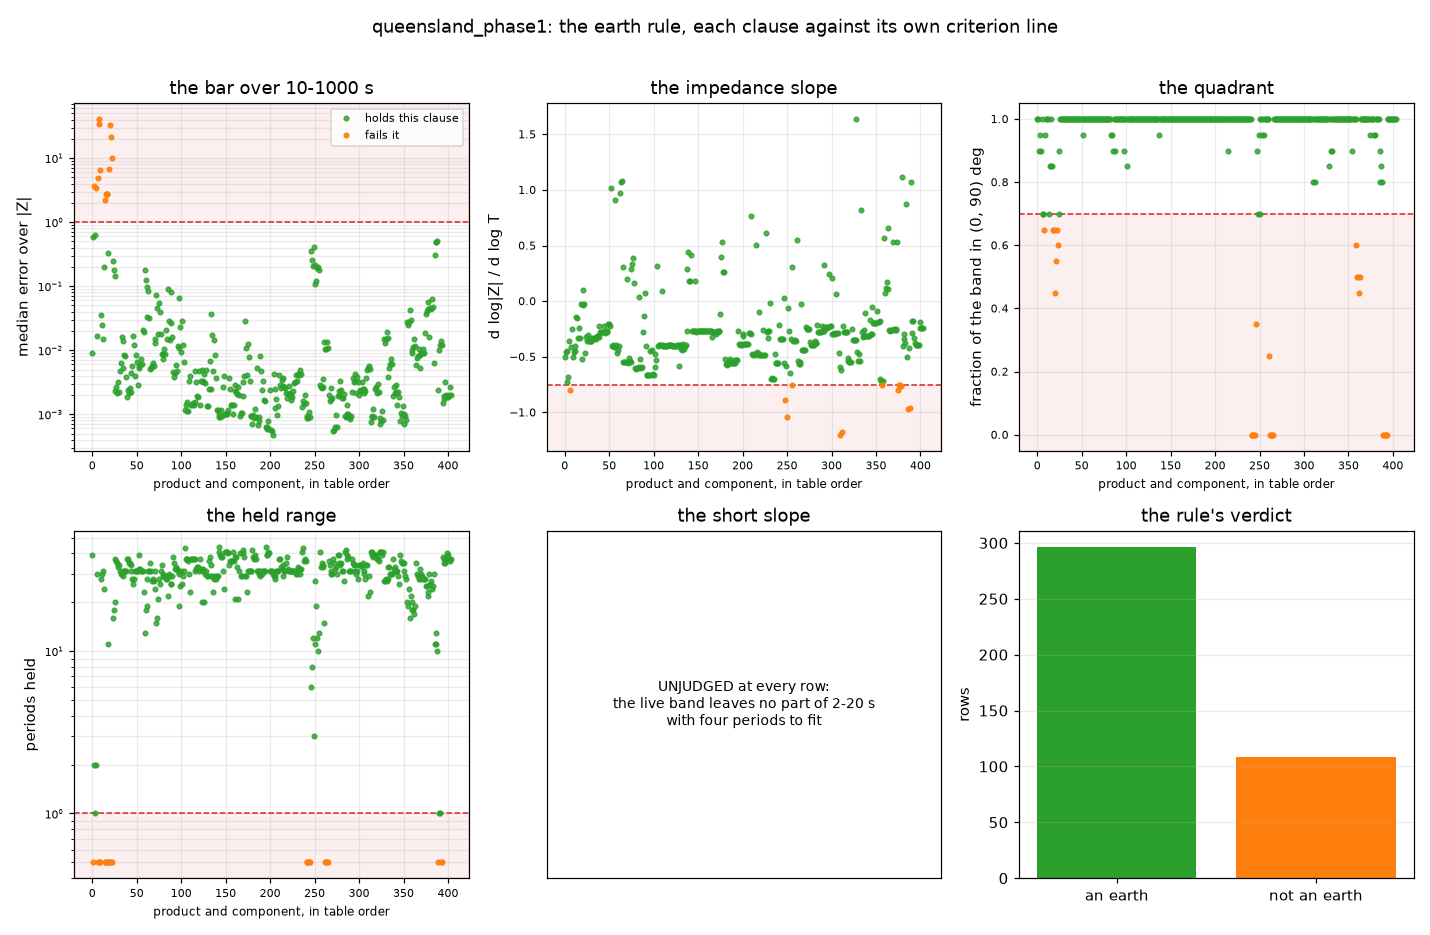


-> E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\READINGS.csv (408 rows)
VERDICT: PASS -- every one of the 204 EDI(s) in the chosen run folders is in the readings table, and all 296 rows flagged as earths hold held_n > 0, a bar at or under 1.00 and an impedance slope at or above -0.75 when the three are recomputed from the files themselves


In [4]:
t_read = time.time()
READINGS = RD.readings_table(PROD, read=read, band=tuple(QUALITY_BAND), live=LIVE,
                             agree_band=tuple(AGREE_BAND), agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE,
                             slope_tol=SLOPE_TOL, z_slope_cut=Z_SLOPE_CUT, bar_max=BAR_MAX)
print("%d readings over %d product(s) in %.1f s" % (len(READINGS), len(PROD), time.time() - t_read))
print()
cols = ["site", "component", "kind", "selection", "form", "rate_hz", "earth", "quadrant", "continuous",
        "short_slope", "z_slope", "bar_10_1000", "rho_bar_10_1000", "held_n", "held_hi_s", "agree_n"]
first = CHOSEN[0] if CHOSEN else ""
print("the readings of %s, as an example of the table" % first)
print(READINGS[READINGS.site == first][cols].round(4).to_string(index=False))
print()
print("earths per kind, selection and component, over %d site(s)" % len(CHOSEN))
print(READINGS[READINGS.status == "ok"].pivot_table(index=["kind", "selection"], columns="component",
                                                    values="earth", aggfunc="sum").to_string())
print()
print("why a row is not an earth, the leading clause of each")
lead = (READINGS[(READINGS.status == "ok") & (~READINGS.earth.astype(bool))]
        .not_earth_because.str.split(";").str[0].str.split("(").str[0].str.strip())
print(lead.value_counts().to_string())

# the three guards worked out again from each EDI, not read back from the table above
bad_flag, missing = [], []
in_table = {str(p).lower() for p in READINGS.path}
for folder in sorted({Path(p).parent for p in PROD.path}):
    for p in sorted(Path(folder).glob("*.edi")):
        if str(p).lower() not in in_table:
            missing.append(str(p))
for r in READINGS[READINGS.earth.astype(bool)].itertuples():
    tf = read(r.path)
    i, j = PR.COMPONENTS[r.component]
    per = np.asarray(tf.period, float)
    zz, ee = tf.z[:, i, j], np.asarray(tf.z_err, float)[:, i, j]
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = ee / np.abs(zz)
    ph = np.degrees(np.angle(zz)) + (180.0 if r.component == "yx" else 0.0)
    ph = np.where(ph > 180, ph - 360, ph)
    held_n = int(np.sum(np.isfinite(rel) & (rel < 0.20) & (ph >= 0) & (ph <= 90)))
    band = (per >= QUALITY_BAND[0]) & (per <= QUALITY_BAND[1]) & np.isfinite(rel)
    bar = float(np.median(rel[band])) if band.any() else np.nan
    fit = band & np.isfinite(zz) & (np.abs(zz) > 0)
    zsl = (float(np.polyfit(np.log10(per[fit]), np.log10(np.abs(zz[fit])), 1)[0])
           if fit.sum() >= 4 else np.nan)
    why = []
    if held_n <= 0:
        why.append("held_n %d" % held_n)
    if np.isfinite(bar) and bar > BAR_MAX:
        why.append("bar %.3f" % bar)
    if np.isfinite(zsl) and zsl < Z_SLOPE_CUT:
        why.append("z_slope %.3f" % zsl)
    if why:
        bad_flag.append("%s %s %s/%s: %s" % (r.site, r.component, r.kind, r.selection, ", ".join(why)))

path = OUT / "READINGS.csv"
READINGS.round(6).to_csv(path, index=False)
WRITTEN.append(path)
fig_rule = FIG.rule_page(READINGS, OUT / "06_earth_rule.png", bar_max=BAR_MAX,
                         z_slope_cut=Z_SLOPE_CUT, slope_tol=SLOPE_TOL,
                         title="%s: the earth rule, each clause against its own criterion line"
                               % sv.cfg["name"])
WRITTEN.append(fig_rule)
display(Image(filename=str(fig_rule)))
print()
print("-> %s (%d rows)" % (path, len(READINGS)))

n_scored = int((READINGS.status == "ok").sum())
if not n_scored:
    print("VERDICT: UNJUDGED -- no product of the chosen sites could be read, so no row was scored")
elif missing or bad_flag:
    print("VERDICT: FAIL -- %d EDI(s) in the chosen run folders are missing from the readings table (%s); "
          "%d row(s) are flagged as earths while failing a guard recomputed from the file (%s)"
          % (len(missing), "; ".join(Path(m).name for m in missing[:4]) or "none", len(bad_flag),
             "; ".join(bad_flag[:4]) or "none"))
else:
    print("VERDICT: PASS -- every one of the %d EDI(s) in the chosen run folders is in the readings table, "
          "and all %d rows flagged as earths hold held_n > 0, a bar at or under %.2f and an impedance slope "
          "at or above %+.2f when the three are recomputed from the files themselves"
          % (len(in_table), int(READINGS.earth.astype(bool).sum()), BAR_MAX, Z_SLOPE_CUT))


## 2. Agreement between the products

Every pair of products of one site and component, scored over AGREE_BAND. Two products agree where the
median departure in apparent resistivity is within AGREE_RHO and the median departure in phase is within
AGREE_PHASE -- 20 per cent and 5 deg over 5-200 s at the values above. The departure is the median of the
absolute differences and not the difference of the medians, so a curve that wobbles about another by more
than the tolerance is not called agreement; the median ratio and the median phase difference workbook 04
reports are carried in the same row beside it.

What to look for. Agreement between two kinds that share no magnetics is the evidence that neither is
carrying its own noise into the estimate. A single station agreeing with nothing at the short end is the
expected reading and not a fault: its own H noise is coherent with itself. A site where every referenced
kind agrees and the single station does not is a site whose reference bought something; a site where
nothing agrees with anything is a site whose record does not support a delivered row, and section 3 says so.

This is a reading and not a check.

In [5]:
t_ag = time.time()
PAIRS = pd.concat([RD.agreement_matrix(PROD, read=read, comp=c, agree_band=tuple(AGREE_BAND),
                                       agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE)
                   for c in RD.COMPONENTS], ignore_index=True)
print("%d pair(s) scored over %g-%g s in %.1f s" % (len(PAIRS), AGREE_BAND[0], AGREE_BAND[1],
                                                    time.time() - t_ag))
print()
cross = PAIRS[~PAIRS.same_kind]
by_site = (cross.groupby(["site", "component"])
           .agg(pairs=("agrees", "size"), agreeing=("agrees", "sum"),
                worst_rho_dev=("rho_dev", "max"), worst_phase_dev=("phase_dev_deg", "max"))
           .reset_index().round(3))
print("pairs of DIFFERENT kinds, which is what the product of record is chosen on")
print(by_site.to_string(index=False))
print()
print("the agreement matrix of %s, component xy: the median departure in rho" % first)
ex = PAIRS[(PAIRS.site == first) & (PAIRS.component == "xy")]
if len(ex):
    print(ex.pivot_table(index="a", columns="b", values="rho_dev").round(3).to_string())
    print()
    print("the same pairs in phase, deg")
    print(ex.pivot_table(index="a", columns="b", values="phase_dev_deg").round(2).to_string())
print()
print("the earths and how many products of another kind each agrees with")
counts = (READINGS[READINGS.earth.astype(bool)]
          .groupby(["site", "component"]).agree_n.agg(["size", "max"])
          .rename(columns={"size": "earths", "max": "most_agreeing"}).reset_index())
print(counts.to_string(index=False))


2724 pair(s) scored over 5-200 s in 0.2 s

pairs of DIFFERENT kinds, which is what the product of record is chosen on
  site component  pairs  agreeing  worst_rho_dev  worst_phase_dev
   Q49        xy     58         1          5.357           47.657
   Q49        yx     58         1      24634.274           64.121
   Q50        xy     58        58          0.064            3.651
   Q50        yx     58        54          0.236            1.343
   Q51        xy     58        18      14117.560           25.993
   Q51        yx     58        18        250.047           15.558
  Q52N        xy     58        18        116.825           14.842
  Q52N        yx     58        18          3.127            8.629
  Q53N        xy    330        77         46.120           35.659
  Q53N        yx    330        79         49.569            7.197
  Q60N        xy     79        79          0.183            1.120
  Q60N        yx     79        59          0.310            1.634
  Q61N        xy     25 

## 3. The product of record

Per site and component: the choice, the bars of the alternatives and the tie-break, or `none` with the
reason there is none. The pool is the earths that agree with a product of another kind; inside it the choice
is the smallest bar over QUALITY_BAND, ties broken by the longest period held.

The choice is made among the products at the delivery rate, `RECORD_RATES`, which is 1 Hz. A 10 Hz product
of this survey stops near 1,200 s, and the row a long-period survey delivers has to cover the delivery band;
the 10 Hz short end enters the file through the splice of section 5, where it joins the chosen row at 16 s,
and not as the whole row.

Which products may be delivered is workbook 05's call and not this one's. A workbook 03 product may always
be delivered; a form may only where its forms.csv row marks it a candidate, which it does where the form
beats every control it carries on the 10-1000 s bar by 20 per cent and is not an inter-site impedance. A
form that is not a candidate is read, scored and reported in section 1, is never the product of record, and
does not corroborate another row: a selection of hours that does not beat a random selection of the same
size bought efficiency, not a different answer, and it cannot vouch for anything either.

A component with no product of record is a result. Two shapes of it are reported apart because they mean
different things: a component whose rows are earths that do not corroborate each other is one where the
references disagree, and a component with no earth at all is one whose record carries no transfer function
of that orientation.

**This check fails if any chosen product is not an earth, or does not agree with at least one product of
another kind, or is not the smallest bar among the products that satisfy both and that forms.csv admits.**
All three are recomputed in this cell from the readings table's own columns rather than read back from the
choice.

The figure is the choice as it was made: every product's bar at one site as a point, filled where the row is
an earth that agrees with another kind, open where it is an earth agreeing with nothing, a cross where it is
not an earth, and ringed where the rule chose it. What to look for: a column of open circles with no ring is
a component whose references disagree, and a column of crosses alone is a component with no earth to
choose.

the product of record, per site and component
  site component     product      kind_word  bar_10_1000   held_hi_s  held_n  agree_n                 agree_kinds
   Q49        xy        none                         NaN         NaN     0.0        0                            
   Q49        yx        none                         NaN         NaN     0.0        0                            
   Q50        xy  stack 1 Hz    fleet stack      0.00214  5786.97006    35.0        4 obs remote single stack_obs
   Q50        yx single 1 Hz single station      0.00183  5786.97006    37.0        4  obs remote stack stack_obs
   Q51        xy remote 1 Hz    remote site      0.00571 12117.61062    32.0        3         obs stack stack_obs
   Q51        yx remote 1 Hz    remote site      0.00524  8339.91492    31.0        3         obs stack stack_obs
  Q52N        xy remote 1 Hz    remote site      0.00720  3029.40247    30.0        3         obs stack stack_obs
  Q52N        yx remote 1 Hz    remote sit

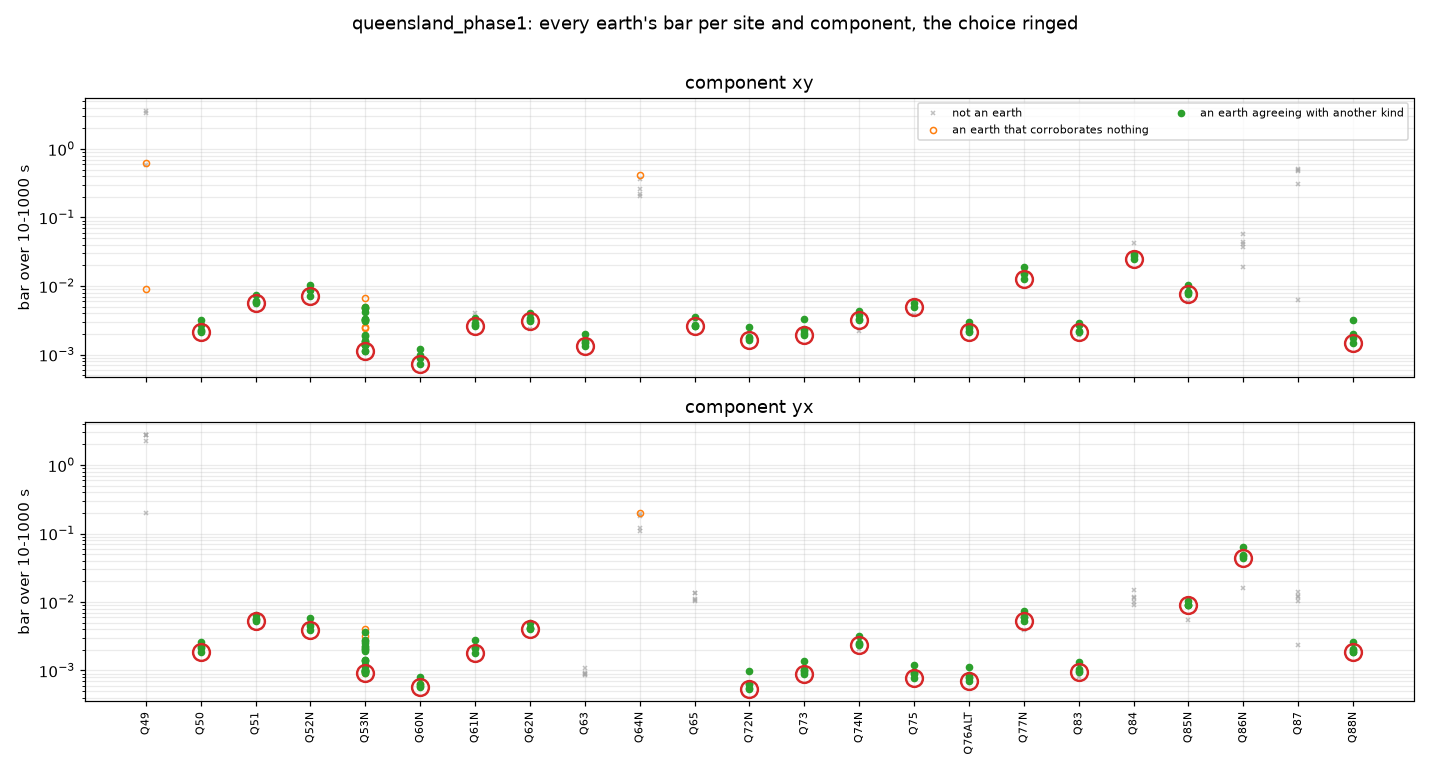

VERDICT: PASS -- all 36 products of record are earths, agree with at least one other kind and carry the smallest bar over 10-1000 s among the products that do; the 10 site-component(s) with none have no agreeing earth at 1 Hz


In [6]:
RECORD = RD.product_of_record(READINGS, bar_max=BAR_MAX, agree_band=tuple(AGREE_BAND),
                              band=tuple(QUALITY_BAND), rates=[float(r) for r in RECORD_RATES])
show = ["site", "component", "product", "kind_word", "bar_10_1000", "held_hi_s", "held_n", "agree_n",
        "agree_kinds"]
print("the product of record, per site and component")
print(RECORD[show].round(5).to_string(index=False))
print()
none = RECORD[RECORD["product"] == "none"]
print("%d of %d site-components have no product of record" % (len(none), len(RECORD)))
if len(none):
    print(none[["site", "component", "why"]].to_string(index=False))
print()
print("the alternatives each choice was made among, the first ten")
for r in RECORD[RECORD["product"] != "none"].head(10).itertuples():
    print("  %-8s %s  %-20s  <- %s" % (r.site, r.component, r.product, r.why))
    print("     the earths and their bars: %s" % r.alternatives)

# recomputed here from the readings, not read back from the choice
wrong = []
pool_all = READINGS[(READINGS.status == "ok")
                    & (READINGS.rate_hz.isin([float(x) for x in RECORD_RATES]))
                    & ((READINGS.form == "") | READINGS.candidate.astype(bool))]
for r in RECORD[RECORD["product"] != "none"].itertuples():
    g = pool_all[(pool_all.site == r.site) & (pool_all.component == r.component)]
    row = g[g.path == r.path]
    if not len(row):
        wrong.append("%s %s: the chosen product is not in the pool" % (r.site, r.component))
        continue
    row = row.iloc[0]
    pool = g[g.earth.astype(bool) & (g.agree_n > 0)]
    if not bool(row.earth):
        wrong.append("%s %s: the chosen product is not an earth" % (r.site, r.component))
    elif int(row.agree_n) < 1:
        wrong.append("%s %s: the chosen product agrees with no other kind" % (r.site, r.component))
    elif not len(pool) or float(row.bar_10_1000) > float(pool.bar_10_1000.min()) * (1 + 1e-9):
        wrong.append("%s %s: bar %.5f, the smallest in the pool is %.5f"
                     % (r.site, r.component, row.bar_10_1000,
                        float(pool.bar_10_1000.min()) if len(pool) else np.nan))
for r in none.itertuples():
    g = pool_all[(pool_all.site == r.site) & (pool_all.component == r.component)]
    pool = g[g.earth.astype(bool) & (g.agree_n > 0)]
    if len(pool):
        wrong.append("%s %s: called none while %d agreeing earth(s) exist"
                     % (r.site, r.component, len(pool)))

fig_rec = FIG.record_page(READINGS[READINGS.rate_hz.isin([float(x) for x in RECORD_RATES])], RECORD,
                          OUT / "06_product_of_record.png",
                          title="%s: every earth's bar per site and component, the choice ringed"
                                % sv.cfg["name"])
WRITTEN.append(fig_rec)
display(Image(filename=str(fig_rec)))

n_chosen = int((RECORD["product"] != "none").sum())
if not len(RECORD):
    print("VERDICT: UNJUDGED -- no site-component was scored, so no product of record was chosen")
elif wrong:
    print("VERDICT: FAIL -- %d of %d choices do not satisfy the rule when it is recomputed (%s)"
          % (len(wrong), len(RECORD), "; ".join(wrong[:5])))
else:
    print("VERDICT: PASS -- all %d products of record are earths, agree with at least one other kind and "
          "carry the smallest bar over %g-%g s among the products that do; the %d site-component(s) with "
          "none have no agreeing earth at %s Hz"
          % (n_chosen, QUALITY_BAND[0], QUALITY_BAND[1], len(none),
             ", ".join(str(x) for x in RECORD_RATES)))


## 4. Reproducibility on halves

A product of record is re-estimated twice, once on each half of its own record, and the two are put through
the agreement rule over QUALITY_BAND. A product whose two halves disagree was estimated on something that
changed inside the record.

The record is not cut. Each half is a keep mask handed to the estimator on top of the transient mask, so the
mask is applied inside the pass and one Aurora run is written per kept stretch, exactly as the whole-record
product was. The split is at the midpoint sample index, so the two halves are the same length whatever the
gaps hold; the days each half keeps after the transient mask are reported beside the verdict, because a
record whose second half is mostly masked reproduces on a shorter record than its first.

The cost is two passes per candidate. Only the candidates are run -- the products the rule chose, not every
product -- and the count and the time are reported below. `HALVES` False reads the passes already on disk
and leaves the reading UNJUDGED where there are none.

A candidate that does not reproduce is flagged in the delivery record and is not removed: the rule chose it
on its soundness and its corroboration, and the reason it did not reproduce is written beside it for a
reader to weigh.

**This check fails if the halves are UNJUDGED for every candidate -- no half pass ran and none was found on
disk.** A reading over no items cannot support the column it fills.

Two figures: the departure of each candidate's two halves from each other against the two criterion lines,
and one candidate's two half curves drawn against the whole-record product they were split from. What to look
for in the second: the halves should sit on the whole record through the middle band and part at the long
end, where each half carries half the independent windows and its bars grow.

29 candidate product(s) of record, 20 site lane job(s), stamp 20260916_2356 (resumed)
  site   kind  rate_hz selection form   run         stamp components
   Q50 single      1.0     whole      first 20260916_1054         yx
   Q50  stack      1.0     whole      first 20260916_1054         xy
   Q51 remote      1.0     whole      first 20260916_1054      xy yx
  Q52N remote      1.0     whole      first 20260916_1054      xy yx
  Q53N  stack      1.0     whole      first 20260916_1054      xy yx
  Q60N single      1.0     whole      first 20260916_1054         xy
  Q60N  stack      1.0     whole      first 20260916_1054         yx
  Q61N remote      1.0     whole      first 20260916_1054         yx
  Q61N  stack      1.0     whole      first 20260916_1054         xy
  Q62N remote      1.0     whole      first 20260916_1054      xy yx
   Q63 single      1.0     whole      first 20260916_1054         xy
   Q65  stack      1.0     whole      first 20260916_1054         xy
  Q72N remote    

 1/20 Q50       single,stack           exit 0     3.5 s 


 2/20 Q51       remote                 exit 0     3.5 s 


 3/20 Q52N      remote                 exit 0     3.5 s 


 4/20 Q53N      stack                  exit 0     3.3 s 


...

17/20 Q84       remote                 exit 0     3.3 s 


18/20 Q85N      remote,stack           exit 0     3.4 s 


19/20 Q86N      stack                  exit 0     3.2 s 


20/20 Q88N      remote,single          exit 0     3.3 s 



29 candidate(s), two half passes each; 0.4 min of wall time in this cell
  site   kind  rate_hz component  half1_days  half2_days  rho_dev  phase_dev_deg  n reproducible
   Q50 single      1.0        xy      29.882      28.583   0.0175         0.2902 20          yes
   Q50 single      1.0        yx      29.882      28.583   0.0091         0.2319 20          yes
   Q50  stack      1.0        xy      29.882      28.569   0.0383         0.4657 20          yes
   Q50  stack      1.0        yx      29.882      28.569   0.0092         0.3413 20          yes
   Q51 remote      1.0        xy      27.785      19.159   0.0570         0.4759 20          yes
   Q51 remote      1.0        yx      27.785      19.159   0.0397         0.7477 20          yes
  Q52N remote      1.0        xy      13.861      17.909   0.0604         0.5679 20          yes
  Q52N remote      1.0        yx      13.861      17.909   0.0681         1.2813 20          yes
  Q53N  stack      1.0        xy      30.226      28.

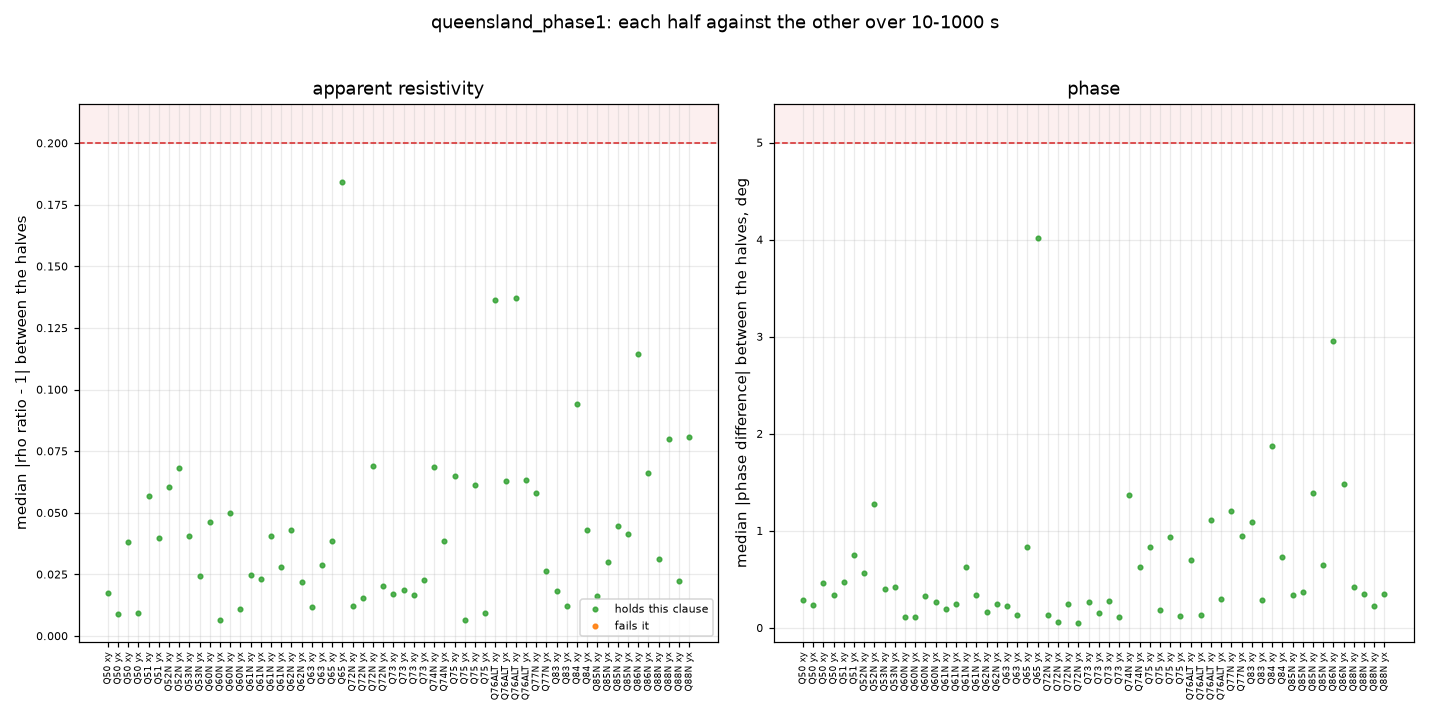

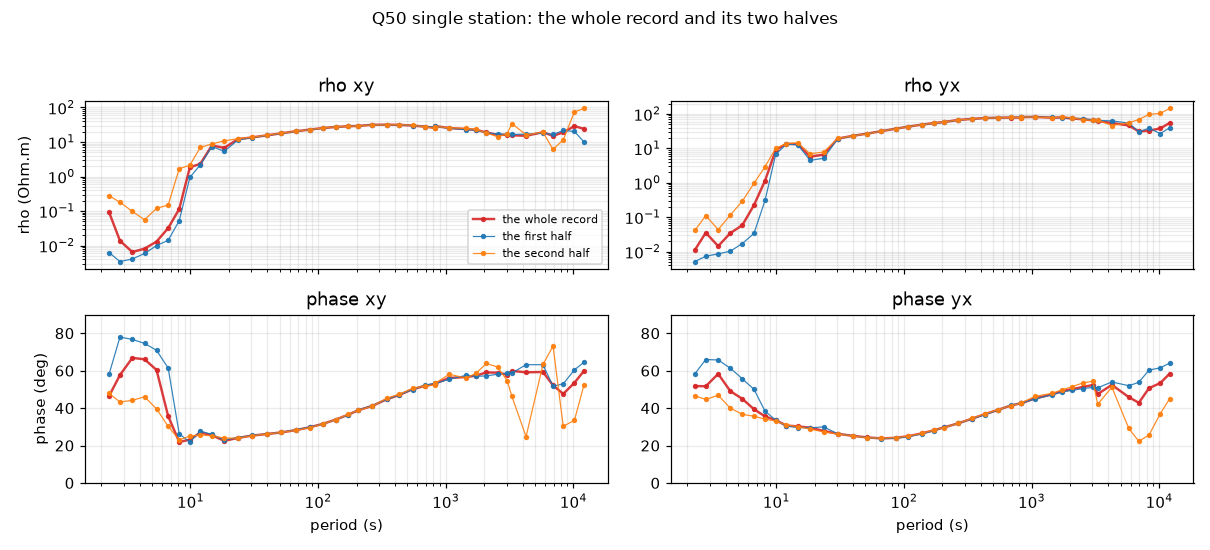

VERDICT: PASS -- 58 of 58 candidate-component readings were scored on two half passes each; 58 reproduce within 20 % in rho and 5.0 deg in phase over 10-1000 s and 0 do not (none), which is flagged in the delivery record and not removed


In [7]:
import subprocess
import concurrent.futures as cf

CAND = RD.candidates(RECORD)
_stamps = sorted([s for s in {RD.split_run_folder(p.name)[1] for site in CHOSEN
                              for p in (WORK / site).glob("halves_*") if p.is_dir()} if s])
HALF_STAMP = _stamps[-1] if _stamps else datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")
print("%d candidate product(s) of record, %d site lane job(s), stamp %s (%s)"
      % (len(CAND), CAND.groupby(["site", "rate_hz"]).ngroups if len(CAND) else 0, HALF_STAMP,
         "resumed" if _stamps else "new"))
print(CAND.to_string(index=False))

ENV = dict(os.environ)
ENV.update(OMP_NUM_THREADS="3", MKL_NUM_THREADS="3", OPENBLAS_NUM_THREADS="3")   # <- 3 threads a lane

def one_site(job):
    """One lane: every candidate kind of one site in turn. Two lanes on one site would share a scratch."""
    site, rate, kinds = job
    cmd = [sys.executable, "-m", "auslamp_proc.halves", "--survey", SURVEY, "--site", site,
           "--rate", str(int(rate)), "--stamp", HALF_STAMP, "--quiet", "--kinds"] + list(kinds)
    if WORK_ROOT:
        cmd += ["--work-root", str(WORK_ROOT)]
    t = time.time()
    r = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True, env=ENV)
    return site, ",".join(kinds), r.returncode, round(time.time() - t, 1), (r.stderr or "").strip()[-200:]

t_half = time.time()
if HALVES and len(CAND):
    jobs = (CAND.groupby(["site", "rate_hz"])["kind"].apply(lambda v: sorted(set(v)))
            .reset_index().values.tolist())
    print()
    print("%d lane job(s) over %d lane(s); a half pass already on disk is reported and not remade"
          % (len(jobs), LANES), flush=True)
    done = 0
    with cf.ThreadPoolExecutor(max_workers=LANES) as ex:
        for site, kinds, rc, secs, err in ex.map(one_site, jobs):
            done += 1
            print("%2d/%2d %-9s %-22s exit %d %7.1f s %s" % (done, len(jobs), site, kinds, rc, secs,
                                                             err if rc else ""), flush=True)
HALF_RECORDS = []
for r in CAND.itertuples():
    rec = HV.read_existing(WORK, r.site, r.kind, int(r.rate_hz), stamp=HALF_STAMP,
                           band=tuple(QUALITY_BAND), agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE)
    if rec is None:
        rec = dict(site=r.site, kind=r.kind, rate_hz=float(r.rate_hz), params="", stamp=HALF_STAMP,
                   half1="", half2="", half1_days=None, half2_days=None, seconds=None,
                   error="no half pass on disk", components={})
    HALF_RECORDS.append(rec)
HALF = HV.halves_table(HALF_RECORDS, out_path=OUT / "HALVES.csv")
WRITTEN.append(OUT / "HALVES.csv")
print()
print("%d candidate(s), two half passes each; %.1f min of wall time in this cell"
      % (len(CAND), (time.time() - t_half) / 60.0))
print(HALF[["site", "kind", "rate_hz", "component", "half1_days", "half2_days", "rho_dev",
            "phase_dev_deg", "n", "reproducible"]].round(4).to_string(index=False))
print()
print(HALF.reproducible.value_counts().to_string())

# the reading goes into the record beside the choice, never in place of it
rep = {(r.site, r.kind, r.component): (r.reproducible, r.why) for r in HALF.itertuples()}
vals, whys = [], []
for r in RECORD.itertuples():
    v, w = rep.get((r.site, r.kind, r.component), ("UNJUDGED", "no half pass for this product"))
    vals.append(v if r.product != "none" else "")
    whys.append(w)
RECORD["reproducible"] = vals
RECORD["note"] = [("does not reproduce on halves: %s" % w) if v == "no" else n
                  for v, w, n in zip(vals, whys, RECORD.note)]
RECORD["flagged"] = [("not reproducible" if v == "no" else
                      ("halves UNJUDGED" if v == "UNJUDGED" else "")) for v in vals]
fig_half = FIG.halves_page(HALF, OUT / "06_halves.png", agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE,
                           title="%s: each half against the other over %g-%g s"
                                 % (sv.cfg["name"], QUALITY_BAND[0], QUALITY_BAND[1]))
WRITTEN.append(fig_half)
display(Image(filename=str(fig_half)))
shown_half = next((r for r in HALF.itertuples() if r.reproducible != "UNJUDGED"), None)
if shown_half is not None:
    rec = next(r for r in HALF_RECORDS if r["site"] == shown_half.site and r["kind"] == shown_half.kind)
    # the whole-record product is the one the rule CHOSE, taken by its own path: the ledger can name a
    # product of the same site and kind that a failed pass never wrote, and reading that raises
    chose = RECORD[(RECORD.site == rec["site"]) & (RECORD.kind == rec["kind"])
                   & (RECORD["product"] != "none")]
    whole_path = str(chose.iloc[0].path) if len(chose) else ""
    p = FIG.halves_curves(rec["site"], (read(whole_path) if Path(whole_path).exists() else None),
                          read(rec["half1"]), read(rec["half2"]),
                          WORK / rec["site"] / "final" / ("%s_halves.png" % rec["site"]),
                          period_range=tuple(PERIOD_RANGE),
                          title="%s %s: the whole record and its two halves"
                                % (rec["site"], KIND_WORD.get(rec["kind"], rec["kind"])))
    WRITTEN.append(p)
    display(Image(filename=str(p)))

judged = HALF[HALF.reproducible != "UNJUDGED"]
if not len(CAND):
    print("VERDICT: UNJUDGED -- no product of record was chosen, so there was no candidate to re-estimate")
elif not len(judged):
    print("VERDICT: UNJUDGED -- the halves were scored for none of the %d candidate(s): %s"
          % (len(CAND), "; ".join(sorted(set(HALF.why)))[:200]))
else:
    n_no = int((HALF.reproducible == "no").sum())
    print("VERDICT: PASS -- %d of %d candidate-component readings were scored on two half passes each; %d "
          "reproduce within %.0f %% in rho and %.1f deg in phase over %g-%g s and %d do not (%s), which is "
          "flagged in the delivery record and not removed"
          % (len(judged), len(HALF), len(judged) - n_no, 100 * AGREE_RHO, AGREE_PHASE, QUALITY_BAND[0],
             QUALITY_BAND[1], n_no,
             " ".join("%s %s" % (r.site, r.component)
                      for r in HALF[HALF.reproducible == "no"].itertuples()) or "none"))


## 5. The splice: the 10 Hz short end joined at 16 s

The delivered file is the 1 Hz row above the join and a 10 Hz row below it, where the step at the join
holds. Three measurements decide it, in this order.

**The decomposition first.** Each 10 Hz product is read against the 1 Hz product of the same kind over
4-32 s. The median of that ratio over the kinds is the rate effect -- what the two processing paths say
about the same band -- and the spread across kinds at one rate is the kind effect. A survey whose rate
effect exceeds 4 per cent cannot be spliced at all, because the join would deliver the difference between
two processing paths as a bend in the earth. Aurora at 10 Hz reads about 8 per cent low at 4-32 s against
its own 1 Hz product (AusLAMP Victoria, 2026-09-11), and every 10 Hz product carries that sentence in its
own file; this is the measurement that says whether this survey has a short end to deliver.

The gate is read over the whole-record 10 Hz pass and over the random 25 per cent that controls the
selections, and over no other row. A selection of the most coherent hours is not comparable to a 1 Hz
product of the whole record: its departure over 4-32 s carries the selection as well as the rate, and a gate
read over it would refuse the join for a difference the join does not deliver. Every 10 Hz row is in the
table beside the gate, with `in_gate` saying which ones the median was taken over.

**The control gate.** The 10 Hz pass runs on the most coherent hours, so a selection has to earn its place
against a random selection of the same size: a row is eligible only where its 2-16 s impedance bar beats its
kind's `r25` control by CONTROL_MARGIN. A selection that does not beat a random one of the same size buys
efficiency, not a different answer. The whole-record 10 Hz pass is a control rather than a selection and is
admitted without the gate; `r25` itself is never promoted; a selection whose kind has no `r25` product is
UNJUDGED on the gate and is not eligible, and the table says so rather than passing it.

**The acceptance.** The step at the join is measured on two bands and the worse one governs: 8-16 s below,
where the delivered row would be the 10 Hz one, and 32-100 s above, where it is the 1 Hz one. A row whose
worse step exceeds SPLICE_MAX_STEP_PCT is reported not spliced and keeps its 1 Hz row untouched. The band
between them is not scored: SPLICE_GUARD holds the Earth Data logger's 20.6 s instrument line, which is not
an earth response and is reproducible only to 5-14 per cent between honest processing paths, so a 2 per cent
criterion there would measure the line and not the join. The guard band is measured, printed and scored by
nothing.

Inside what the gate and the acceptance leave, the xy row is chosen on its 4-32 s level against the row it
joins and the yx row on its own short-end bar. Nothing below SHORT_FLOOR_S is delivered, and an unspliced
row is the 1 Hz row unchanged.

The 1 Hz rows are merged into `final/<site>_1hz.edi` first, because the row a 10 Hz product joins is the
delivered row and not one of the two sources it came from; that merge is section 6's check and this section
takes it as given.

**This check fails if any period or value of a component that was not spliced differs from its 1 Hz input by
more than 1e-12 relative, or if a spliced row's step exceeds SPLICE_MAX_STEP_PCT on either ruled band, or if
anything below SHORT_FLOOR_S is delivered.** The first limb is the test the frozen tool failed: rounding the
union grid's values moved one period of every unspliced row by 2.3e-7 of itself.

The figure draws both ruled bands against the +-SPLICE_MAX_STEP_PCT lines and the guard band beside them in
grey with no line at all. What to look for: a row whose two bands sit on opposite sides of zero is a row
whose step is a bend and not an offset, and that is what the two-band rule exists to catch; the guard band
panel should scatter more widely than either ruled band, which is why nothing scores it.

the 10 Hz path against the 1 Hz path of the same kind over 4-32 s, in per cent
site   kind      kind_word selection    form component band_s  rate_pct  n  inside
 Q49 remote    remote site       r25                xy   4-32    -20.55 10   False
 Q49 remote    remote site       r25                yx   4-32    109.35 10   False
 Q49 remote    remote site       f05                xy   4-32     46.06 10   False
 Q49 remote    remote site       f05                yx   4-32    -74.12 10   False
 Q49 remote    remote site       f10                xy   4-32     67.49 10   False
 Q49 remote    remote site       f10                yx   4-32    -60.16 10   False
 Q49 remote    remote site       f25                xy   4-32     27.22 10   False
 Q49 remote    remote site       f25                yx   4-32    -70.84 10   False
 Q49 single single station       r25                xy   4-32     22.43 10   False
 Q49 single single station       r25                yx   4-32    102.35 10   False
 Q49 sin

2026-09-17T10:33:19.720824+0800 | WARNING | mt_metadata.timeseries.survey | add_station | line: 624 | Station Q50 already exists, updating metadata


2026-09-17T10:33:19.729736+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute survey.summary.


2026-09-17T10:33:19.729736+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute original_program.version.


2026-09-17T10:33:19.729736+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute original_file.date.


...

2026-09-17T10:33:28.605064+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q88na.hz.translated_azimuth.


2026-09-17T10:33:28.605064+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q88na.hz.type.


2026-09-17T10:33:28.605064+0800 | WARNING | mt_metadata.transfer_functions.io.emtfxml.emtfxml | _parse_comments | line: 808 | Cannot set attribute q88na.hz.units.


20 site(s) merged and spliced in 0.2 min

the splice, per site and component
  site component  spliced   kind selection form  step_pct  step_below_pct  step_above_pct  guard_pct  level_4_32_pct  short_bar  shortest_period_s
   Q50        xy    False                             NaN             NaN             NaN        NaN             NaN        NaN                NaN
   Q50        yx    False                             NaN             NaN             NaN        NaN             NaN        NaN                NaN
   Q51        xy    False                             NaN             NaN             NaN        NaN             NaN        NaN                NaN
   Q51        yx    False                             NaN             NaN             NaN        NaN             NaN        NaN                NaN
  Q52N        xy     True remote       f25         -1.170          -1.170           0.800     -0.192           0.765      0.050              1.073
  Q52N        yx    False                

  site spliced  periods_added  n_base_periods  n_out_periods  worst_period_relative  worst_value_relative   ok
   Q50    none              0              41             41                    0.0                   0.0 True
   Q51    none              0              41             41                    0.0                   0.0 True
  Q52N      xy             12              41             53                    0.0                   0.0 True
  Q53N    none              0              48             48                    0.0                   0.0 True
  Q60N    none              0              48             48                    0.0                   0.0 True
  Q61N   xy yx             12              41             53                    0.0                   0.0 True
  Q62N    none              0              48             48                    0.0                   0.0 True
   Q63    none              0              48             48                    0.0                   0.0 True
 

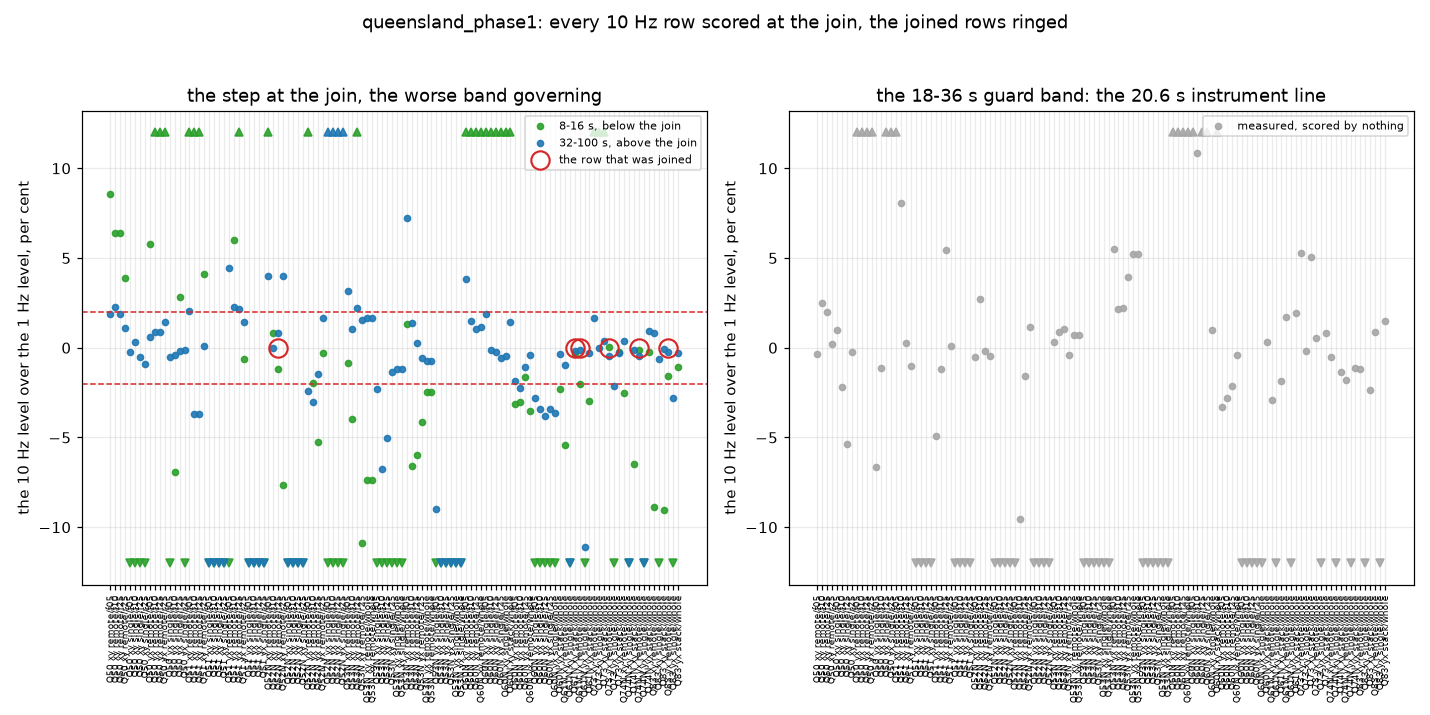

VERDICT: PASS -- 6 of 40 rows joined at 16 s, every one inside 2.0 % on both ruled bands; every unspliced period and value came back identical to its 1 Hz input to better than 1e-12 relative over 20 file(s); nothing below 0.6 s is delivered


In [8]:
DEC = SP.decompose(PROD, read=read, band=tuple(SP.LEVEL_BAND), rate_max_pct=SP.RATE_PATH_MAX_PCT)
if len(DEC):
    print("the 10 Hz path against the 1 Hz path of the same kind over %g-%g s, in per cent"
          % SP.LEVEL_BAND)
    print(DEC.round(2).to_string(index=False))
    print()
    print("the rate against the kind")
    RATE = SP.rate_versus_kind(DEC, SP.RATE_PATH_MAX_PCT)
    print(RATE.round(2).to_string(index=False))
    RATE_OK = {r.component: bool(r.can_splice) for r in RATE.itertuples()}
    print("the rate path gate: %s"
          % ", ".join("%s %s (median %+.2f %%, the ceiling is %.0f %%)"
                      % (r.component, "passes" if r.can_splice else "REFUSES the splice",
                         r.rate_pct_median, SP.RATE_PATH_MAX_PCT) for r in RATE.itertuples()))
else:
    RATE_OK = {}
    print("no site carries both a 1 Hz and a 10 Hz product of the same kind: there is no rate path to read")
print()

def picks_for(site):
    """The record rows of one site as the merge wants them, or an empty dict."""
    out = {}
    for r in RECORD[(RECORD.site == site) & (RECORD["product"] != "none")].itertuples():
        out[r.component] = dict(path=r.path, kind=r.kind, kind_word=r.kind_word, form=r.form,
                                selection=r.selection, run=r.run, stamp=r.stamp, rate_hz=r.rate_hz,
                                bar_10_1000=r.bar_10_1000)
    return out

MERGES, SPLICE_ROWS, SPLICE_SCORED, IDENTITY, DELIVERED = [], [], [], [], {}
t_merge = time.time()
for site in CHOSEN:
    picks = picks_for(site)
    if not picks:
        continue
    base_path = final_dir(site) / ("%s_1hz.edi" % site)
    m = FN.merge(sv, site, picks, base_path, tipper_from=TIPPER_FROM, record=RECORD, verbose=False)
    m["picks"] = picks
    MERGES.append(m)
    if not m.get("written"):
        continue
    shorts = {}
    for r in PROD[(PROD.site == site) & (PROD.rate_hz == 10.0) & PROD.on_disk].itertuples():
        shorts[(r.kind, r.selection, r.form)] = (read(r.path), r.path)
    chosen = {}
    if shorts:
        sel = SP.select_rows(site, read(base_path), shorts, READINGS, join=SPLICE_JOIN_S,
                             max_step_pct=SPLICE_MAX_STEP_PCT, guard=tuple(SPLICE_GUARD),
                             control_band=tuple(CONTROL_BAR_BAND), control_margin=CONTROL_MARGIN,
                             rate_ok=RATE_OK)
        for comp, s in sel.items():
            chosen[comp] = s["pick"]
            p = s["pick"] or {}
            for c in s["scored"]:
                SPLICE_SCORED.append(dict(site=site, component=comp, kind=c["kind"],
                                          selection=c["selection"], form=c.get("form", ""),
                                          earth=c["earth"], eligible=c["eligible"],
                                          control_verdict=c["control_verdict"],
                                          step_below_pct=c["step_below_pct"],
                                          step_above_pct=c["step_above_pct"],
                                          step_pct=c["step_pct"], guard_pct=c["guard_pct"],
                                          level_4_32_pct=c["level_4_32_pct"],
                                          short_bar=c["short_bar"],
                                          chosen=bool(p and c["file"] == p.get("file"))))
            SPLICE_ROWS.append(dict(site=site, component=comp, spliced=bool(s["pick"]),
                                    kind=p.get("kind", ""), kind_word=p.get("kind_word", ""),
                                    selection=p.get("selection", ""), form=p.get("form", ""),
                                    control_verdict=p.get("control_verdict", ""),
                                    bar_2_16=p.get("bar_2_16", np.nan),
                                    control_bar_2_16=p.get("control_bar_2_16", np.nan),
                                    step_pct=p.get("step_pct", np.nan),
                                    step_below_pct=p.get("step_below_pct", np.nan),
                                    step_above_pct=p.get("step_above_pct", np.nan),
                                    guard_pct=p.get("guard_pct", np.nan),
                                    level_4_32_pct=p.get("level_4_32_pct", np.nan),
                                    short_bar=p.get("short_bar", np.nan), earth=p.get("earth", False),
                                    why=s["why"], all_kinds=s["all_kinds"], file=p.get("file", "")))
    else:
        for comp in RD.COMPONENTS:
            SPLICE_ROWS.append(dict(site=site, component=comp, spliced=False, kind="", selection="",
                                    form="", why="no 10 Hz product of this site", all_kinds="", file=""))
    out_path = final_dir(site) / ("%s.edi" % site)
    res = SP.splice(base_path, {c: v for c, v in chosen.items() if v}, out_path, join=SPLICE_JOIN_S,
                    floor=SHORT_FLOOR_S, guard=tuple(SPLICE_GUARD))
    ident = SP.unspliced_unchanged(base_path, out_path, spliced=res["spliced"])
    ident.update(site=site, spliced=" ".join(res["spliced"]) or "none",
                 periods_added=res["periods_added"])
    IDENTITY.append(ident)
    DELIVERED[site] = out_path
    for row in SPLICE_ROWS:
        if row["site"] == site and row["spliced"]:
            pick = chosen.get(row["component"]) or {}
            row["shortest_period_s"] = pick.get("shortest_period_s", np.nan)
            row["n_short_periods"] = pick.get("n_short_periods", 0)

SPLICE = SP.splice_table(SPLICE_ROWS, out_path=OUT / "SPLICE.csv")
WRITTEN.append(OUT / "SPLICE.csv")
print("%d site(s) merged and spliced in %.1f min" % (len(MERGES), (time.time() - t_merge) / 60.0))
print()
print("the splice, per site and component")
print(SPLICE[["site", "component", "spliced", "kind", "selection", "form", "step_pct", "step_below_pct",
              "step_above_pct", "guard_pct", "level_4_32_pct", "short_bar",
              "shortest_period_s"]].round(3).to_string(index=False))
print()
for r in SPLICE.itertuples():
    print("  %-8s %s  %s" % (r.site, r.component, r.why))
print()
if len(SPLICE) and SPLICE.guard_pct.notna().any():
    print("the guard band %g-%g s, measured and scored by nothing: median %+.1f %%, worst %+.1f %%"
          % (SPLICE_GUARD[0], SPLICE_GUARD[1], float(SPLICE.guard_pct.median()),
             float(SPLICE.guard_pct.iloc[int(np.nanargmax(np.abs(SPLICE.guard_pct.values)))])))
print()
ident = pd.DataFrame(IDENTITY)
if len(ident):
    print("every unspliced period and value against its 1 Hz input")
    print(ident[["site", "spliced", "periods_added", "n_base_periods", "n_out_periods",
                 "worst_period_relative", "worst_value_relative", "ok"]].to_string(index=False))

SCORED = pd.DataFrame(SPLICE_SCORED)
if len(SCORED):
    SCORED.round(4).to_csv(OUT / "SPLICE_CANDIDATES.csv", index=False)
    WRITTEN.append(OUT / "SPLICE_CANDIDATES.csv")
    print("every 10 Hz row that was scored, %d of them" % len(SCORED))
    print(SCORED[["site", "component", "kind", "selection", "form", "earth", "eligible",
                  "step_below_pct", "step_above_pct", "guard_pct", "level_4_32_pct", "short_bar",
                  "chosen"]].round(3).to_string(index=False))
    fig_sp = FIG.splice_page(SCORED, OUT / "06_splice.png", max_step_pct=SPLICE_MAX_STEP_PCT,
                             guard=tuple(SPLICE_GUARD),
                             title="%s: every 10 Hz row scored at the join, the joined rows ringed"
                                   % sv.cfg["name"])
    WRITTEN.append(fig_sp)
    display(Image(filename=str(fig_sp)))

shifted = [r.site for r in ident.itertuples() if not r.ok] if len(ident) else []
over = [("%s %s %+.1f %%" % (r.site, r.component, r.step_pct)) for r in SPLICE.itertuples()
        if r.spliced and np.isfinite(r.step_pct) and abs(r.step_pct) > SPLICE_MAX_STEP_PCT]
low = []
for site, p in DELIVERED.items():
    tf = PR.read_tf(p)
    for comp, (i, j) in PR.COMPONENTS.items():
        m = np.isfinite(tf.z[:, i, j])
        if m.any() and float(np.min(tf.period[m])) < SHORT_FLOOR_S:
            low.append("%s %s at %.3f s" % (site, comp, float(np.min(tf.period[m]))))
n_spliced = int(SPLICE.spliced.sum()) if len(SPLICE) else 0
if not len(PROD[PROD.rate_hz == 10.0]):
    print("VERDICT: UNJUDGED -- this survey has no 10 Hz product, so there is no row to join and the splice "
          "is not scored; every delivered file is the 1 Hz row unchanged")
elif shifted or over or low:
    print("VERDICT: FAIL -- %d file(s) moved an unspliced period or value (%s); %d spliced row(s) exceed "
          "%.1f %% at the join (%s); %d row(s) deliver a period below %g s (%s)"
          % (len(shifted), " ".join(shifted) or "none", len(over), SPLICE_MAX_STEP_PCT,
             "; ".join(over) or "none", len(low), SHORT_FLOOR_S, "; ".join(low) or "none"))
else:
    print("VERDICT: PASS -- %d of %d rows joined at %g s, every one inside %.1f %% on both ruled bands; "
          "every unspliced period and value came back identical to its 1 Hz input to better than %.0e "
          "relative over %d file(s); nothing below %g s is delivered"
          % (n_spliced, len(SPLICE), SPLICE_JOIN_S, SPLICE_MAX_STEP_PCT, SP.IDENTITY_TOL, len(ident),
             SHORT_FLOOR_S))


## 6. The final EDI

One file per site in `<work_root>/<site>/final/`. `<site>_1hz.edi` is the merge of the two 1 Hz products of
record and `<site>.edi` is the delivered file, which is that merge with any spliced row joined below 16 s.

The merge takes the first impedance row (Zxx, Zxy) from the xy product of record and the second (Zyx, Zyy)
from the yx product, each with its errors, and the tipper from the product `TIPPER_FROM` names. A product on
another period grid is aligned by nearest period within 1 per cent and never interpolated: an interpolated
row is a third curve and not either product. A component with no product of record leaves its row empty and
the INFO block says so, so a reader cannot take an empty row for a measurement.

A site with no impedance on either component can still deliver its tipper, which is an H-only quantity and
survives two dead electric lines. Its impedance rows are written as the EDI empty-data fill and two INFO
lines name what the file is. The tipper is refused where the vertical channel is not measuring the vertical
field: Hz a copy of a horizontal channel, which reads a coherence of 1.00 with Hx, or Hz carrying the site's
own horizontal field at 1000-4000 s while carrying nothing of a neighbour's vertical field.

The INFO block carries which product each row came from, the flags and the notes per component, the frame
block, the splice line where a 10 Hz row is in the file, the notch record the cache carried, the 10 Hz
caveat and the package version and date. The frame is stated in three lines: the tensor is served in the
frame it was processed in, the IGRF declination is recorded and not applied, and the angle to turn the
tensor by for true geographic north is given with the transformation.

**This check fails if any merged file does not read back with its rows equal to its sources to 1e-9
relative, or if the two-source control fails where the two sources carry different yx rows, or if any
delivered file lacks the frame block or the declination.** The control is what says the merge took rows from
two files: the merged Zyx must differ from the xy source's wherever the two sources differ there.

In [9]:
TIPPER_ONLY = []
for site in CHOSEN:
    if picks_for(site):
        continue
    g = READINGS[(READINGS.site == site) & (READINGS.status == "ok") & (READINGS.rate_hz == 1.0)
                 & (READINGS.form == "")]
    if not len(g) or not g.bar_10_1000.notna().any():
        continue
    src = g.loc[g.bar_10_1000.idxmin()]
    if read(src.path).t is None:
        continue
    try:
        refusal = DL.tipper_refusal(sv, site)
    except Exception as exc:
        refusal = dict(site=site, judged=False, refused=False,
                       reason="the refusal test could not run: %s" % str(exc)[:80])
    out = FN.tipper_only(sv, site, src.path, final_dir(site) / ("%s.edi" % site), kind=src.kind_word,
                         refusal=refusal, record=RECORD)
    out["picks"] = {"tipper": dict(path=src.path, kind=src.kind, form=src.form, run=src.run,
                                   stamp=src.stamp, rate_hz=src.rate_hz)}
    TIPPER_ONLY.append(out)
    if out.get("written"):
        DELIVERED[site] = Path(out["path"])
    print("   %-8s tipper only from the %s product: %s" % (site, src.kind_word, out.get("reason", "")))

print()
print("%d merged file(s), %d tipper-only file(s), %d chosen site(s) with nothing to deliver"
      % (len(MERGES), len([t for t in TIPPER_ONLY if t.get("written")]), len(CHOSEN) - len(DELIVERED)))
mtab = pd.DataFrame([dict(site=m["site"], file=Path(m["path"]).name, xy=m.get("xy", ""),
                          yx=m.get("yx", ""), tipper=m.get("tipper_from", ""),
                          periods=m.get("n_periods", 0),
                          readback=("%.1e" % m.get("worst_readback_relative", np.nan)),
                          check=("PASS" if m.get("ok") else "FAIL"), control=m.get("control", ""),
                          xml=("yes" if m.get("xml") else ("no: " + str(m.get("xml_error", ""))[:40])))
                     for m in MERGES])
print(mtab.to_string(index=False))
print()
shown = SHOW or (sorted(DELIVERED)[0] if DELIVERED else "")
if shown:
    print("the INFO block of %s" % shown)
    for line in PR.read_tf(DELIVERED[shown]).meta["lines"]:
        print("   %s" % line)

no_frame = []
for site, p in sorted(DELIVERED.items()):
    kv = PR.read_tf(p).meta["parameters"]
    lack = [k for k in ("reference_frame", "declination_deg", "to_geographic_north_deg")
            if not str(kv.get(k, "")).strip()]
    if lack:
        no_frame.append("%s: %s" % (site, ", ".join(lack)))
bad_merge = [m["site"] for m in MERGES if not m.get("ok")]
no_control = [m["site"] for m in MERGES if "control FAIL" in str(m.get("control", ""))]
if not MERGES and not TIPPER_ONLY:
    print("VERDICT: UNJUDGED -- no site has a product of record on either component, so no file was written")
elif bad_merge or no_frame:
    print("VERDICT: FAIL -- %d merged file(s) do not read back equal to their sources to %.0e relative or "
          "fail the two-source control (%s; control failures %s); %d delivered file(s) lack a frame line "
          "(%s)" % (len(bad_merge), FN.READBACK_RTOL, " ".join(bad_merge) or "none",
                    " ".join(no_control) or "none", len(no_frame), "; ".join(no_frame) or "none"))
else:
    n_control = sum(1 for m in MERGES if "control PASS" in str(m.get("control", "")))
    print("VERDICT: PASS -- all %d merged file(s) read back with every row equal to its source to better "
          "than %.0e relative; the two-source control holds at the %d site(s) whose two sources carry "
          "different yx rows and is n/a at the other %d; all %d delivered file(s) carry the frame, the "
          "declination and the angle to geographic north"
          % (len(MERGES), FN.READBACK_RTOL, n_control, len(MERGES) - n_control, len(DELIVERED)))


   Q49      tipper only from the single station product: the impedance rows are blank and the tipper is the single station product's


   Q64N     tipper only from the single station product: the impedance rows are blank and the tipper is the single station product's


   Q87      tipper only from the single station product: the impedance rows are blank and the tipper is the single station product's

20 merged file(s), 3 tipper-only file(s), 0 chosen site(s) with nothing to deliver
  site           file     xy     yx tipper  periods readback check                                                                          control xml
   Q50    Q50_1hz.edi  stack single     xy       41  0.0e+00  PASS control PASS (the yx row follows the yx source and differs from the xy source's) yes
   Q51    Q51_1hz.edi remote remote     xy       41  0.0e+00  PASS                              control n/a (the two source files share the yx row) yes
  Q52N   Q52N_1hz.edi remote remote     xy       41  0.0e+00  PASS                              control n/a (the two source files share the yx row) yes
  Q53N   Q53N_1hz.edi  stack  stack     xy       48  0.0e+00  PASS                              control n/a (the two source files share the yx row) yes
  Q60N   Q60N_1hz.edi s

VERDICT: PASS -- all 20 merged file(s) read back with every row equal to its source to better than 1e-09 relative; the two-source control holds at the 9 site(s) whose two sources carry different yx rows and is n/a at the other 11; all 23 delivered file(s) carry the frame, the declination and the angle to geographic north


## 7. The final against the products it came from, and last against the comparisons

Per site, the delivered curve with the products of record under it in the kind colours, the earths the rule
rejected in grey, and any declared comparison source in black behind everything. The delivered curve and the
products it came from are the same numbers wherever the merge took a whole row; where they part, a row came
from somewhere else and the splice line in the file says which.

The comparison comes last and is labelled a comparison, never the truth, for one reason: two independent
processings of the same field are two measurements and neither is an oracle. A difference in level is a
gain, a dipole length or a frame before it is the earth, and a difference the declination turn removes was
never a difference in the earth at all. Every source declares the frame its tensors are in, in
`surveys/<SURVEY>/survey.yaml`, and a source that declares none is refused: a tensor drawn on our axes in an
undeclared frame is a different object on the same picture.

The reading per site and component is the same three explanations a difference can have -- a scale is a
constant ratio with the phase untouched, a frame is a disagreement the declination turn removes, a fault is
neither. It is a reading and not a check.

source       earlier_processing
  folder     E:/MT_Timeseries_DATA/MT_AusLAMP_QLD/processed_2026/phase1_v1
  frame      geomagnetic
  note       Ben's September 2026 Aurora processing of Phase 1, single station and remote site, 1 Hz and 10 Hz; the same raw data through a different code path, rotated so each site's mean Hy i
source       campaign_merged
  folder     E:/MT_Timeseries_DATA/MT_AusLAMP_QLD/processed_2026/final_2026-09-09/merged_edi
  frame      geomagnetic
  note       the September 2026 campaign's deliverable, one merged EDI per station (qld_merge_edis.py, 2026-09-09): a 1 Hz long file, a middle piece below 100 s where a clean window beat the wh



23 final page(s) written


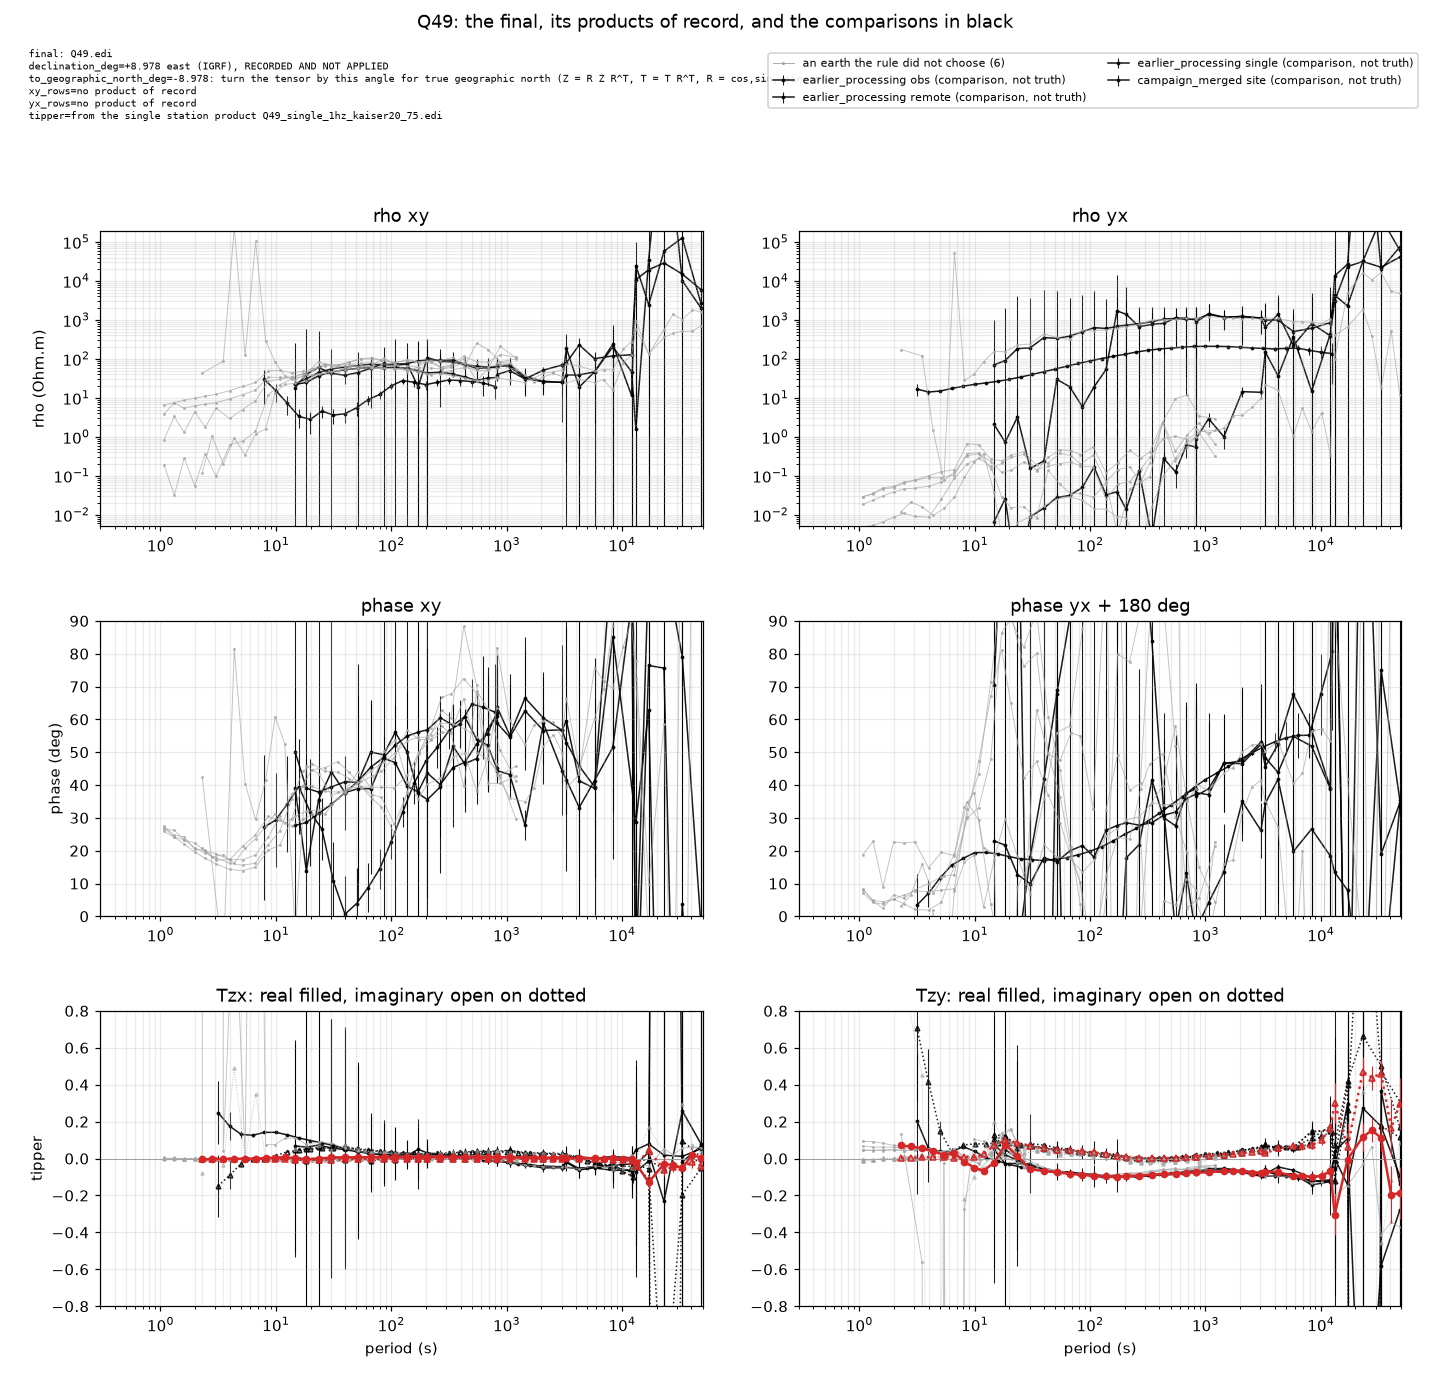

In [10]:
SOURCES = PR.comparison_sources(sv, COMPARE)
for src in SOURCES:
    print("source       %s" % src["name"])
    print("  folder     %s" % src["folder"])
    print("  frame      %s" % (src["frame"] or "NOT DECLARED"))
    print("  note       %s" % (src["note"] or "NOT DECLARED")[:180])
    if src["error"]:
        print("  REFUSED    %s" % src["error"])

FINAL_TF = {s: read(p) for s, p in sorted(DELIVERED.items())}
COMPS = {}
for site in FINAL_TF:
    got = []
    for src in SOURCES:
        if src["error"]:
            continue
        try:
            loaded = PR.load_comparison(src, site, DECLINATION.get(site))
        except Exception:
            loaded = {}
        for kind, tf in sorted(loaded.items()):
            got.append(("%s %s" % (src["name"], kind or "site"), tf))
    COMPS[site] = got

pages = []
for site in sorted(FINAL_TF):
    picks = picks_for(site)
    sources = [("the %s product of record: %s (%s)" % (comp, KIND_WORD.get(v["kind"], v["kind"]),
                                                       v["kind"]), v["kind"], read(v["path"]))
               for comp, v in sorted(picks.items())]
    used = {str(v["path"]) for v in picks.values()}
    rej = {}
    for r in READINGS[(READINGS.site == site) & READINGS.earth.astype(bool)].itertuples():
        if str(r.path) in used:
            continue
        rej[RD.product_label(r)] = read(r.path)
    head = ["final: %s" % Path(DELIVERED[site]).name]
    # the header band is a fixed-width monospace strip, so a line longer than the canvas runs off it
    head += [(ln if len(ln) <= 150 else ln[:147] + "...")
             for ln in PR.read_tf(DELIVERED[site]).meta["lines"]
             if ln.split("=")[0] in ("xy_rows", "yx_rows", "tipper", "splice_xy", "splice_yx",
                                     "declination_deg", "to_geographic_north_deg")]
    path, _index = FIG.final_page(
        site, FINAL_TF[site], sources=sources, rejected=sorted(rej.items()),
        comparisons=COMPS.get(site, []), out=final_dir(site) / ("%s_final.png" % site),
        header_lines=head, period_range=tuple(PERIOD_RANGE),
        title="%s: the final, its products of record, and the comparisons in black" % site)
    pages.append(path)
WRITTEN += pages
print()
print("%d final page(s) written" % len(pages))
if shown and shown in FINAL_TF:
    display(Image(filename=str(final_dir(shown) / ("%s_final.png" % shown))))


### The final against each comparison, per decade

The table is the final over each declared source: the median ratio of apparent resistivity, the median phase
difference in degrees, and the reading. A ratio above one means our level is the higher of the two. The
frames and the notes are printed above; the numbers are a shape check.

In [11]:
def pseudo_for(src):
    """The finals as a products frame, one row per kind the source offers for that site.

    A per-kind source -- one folder per reference kind -- is read against the final once for each kind it
    delivers, so the table says how the final sits against each of the source's own products rather than
    against whichever one happens to share a key with our choice.
    """
    rows = []
    for s, p in sorted(DELIVERED.items()):
        kinds = sorted(PR.comparison_paths(src, s)) or [""]
        for k in kinds:
            rows.append(dict(site=s, run="final", stamp="", kind=k, rate_hz=1.0, params="",
                             selection="whole", path=str(p), xml="", provenance="", remote=None,
                             members=None, n_runs=None, seconds=None, peak_rss_mb=None,
                             status="made", on_disk=True))
    return pd.DataFrame(rows, columns=PR.PRODUCT_COLUMNS)

VS = {}
for src in SOURCES:
    if src["error"] or not DELIVERED:
        continue
    PSEUDO = pseudo_for(src)
    if not len(PSEUDO):
        continue
    tab = AG.versus_comparison(PSEUDO, src, DECLINATION, read=read, bands=[tuple(b) for b in BANDS],
                               agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE,
                               agree_band=tuple(AGREE_BAND))
    VS[src["name"]] = tab
    mid = tab[(tab.band == AG.band_label(*COMPARE_BAND)) & (tab.n > 0)]
    print("%s -- the final over the source at %g-%g s, frame %s"
          % (src["name"], COMPARE_BAND[0], COMPARE_BAND[1], src["frame"]))
    if not len(mid):
        print("   nothing scored at %g-%g s" % COMPARE_BAND)
        continue
    print(mid.pivot_table(index=["site", "kind"], columns="component",
                          values=["rho_ratio", "phase_diff_deg"]).round(3).to_string())
    print()
    off = mid[(np.abs(mid.rho_ratio - 1.0) > AGREE_RHO) | (np.abs(mid.phase_diff_deg) > AGREE_PHASE)]
    print("   %d of %d site-component rows differ by more than %.0f %% or %.1f deg"
          % (len(off), len(mid), 100 * AGREE_RHO, AGREE_PHASE))
    calls = tab[(tab.band == AG.band_label(*AGREE_BAND)) & (tab.n > 0)]
    print("   the scale / frame / fault reading over %s" % AG.band_label(*AGREE_BAND))
    print(calls.reading.str.split(" ").str[0].value_counts().to_string())
    path = OUT / ("final_vs_%s.csv" % src["name"])
    tab.round(4).to_csv(path, index=False)
    WRITTEN.append(path)
    print("   -> %s (%d rows)" % (path, len(tab)))
    print()


earlier_processing -- the final over the source at 100-1000 s, frame geomagnetic
            phase_diff_deg        rho_ratio       
component               xy     yx        xy     yx
site kind                                         
Q50  obs             0.208  0.098     1.012  0.987
     remote          0.336 -0.031     0.996  0.999
     single          0.370  0.052     1.008  1.000
Q51  obs            -0.013  0.612     1.021  0.974
     remote         -0.113  0.306     1.000  0.994
     single          0.089  0.494     1.183  1.017
Q52N obs            -1.553 -0.843     0.790  1.058
     remote         -4.562 -0.691     1.041  1.055
     single         -4.034 -1.011     1.304  0.990
Q53N obs             0.241  0.036     0.999  1.001
     remote         -0.090  0.075     0.999  0.998
     single          0.080  0.052     1.002  1.004

   2 of 24 site-component rows differ by more than 20 % or 5.0 deg
   the scale / frame / fault reading over 5-200 s
reading
agrees    19
FAULT      5
  

campaign_merged -- the final over the source at 100-1000 s, frame geomagnetic
            phase_diff_deg        rho_ratio       
component               xy     yx        xy     yx
site   kind                                       
Q50                  0.224 -0.074     1.010  1.002
Q51                 -0.092  0.163     1.002  0.997
Q52N                -0.269 -0.007     1.012  0.998
Q53N                 0.020  0.012     0.997  1.002
Q60N                 0.054 -0.090     0.998  1.006
Q61N                 0.095 -0.015     1.014  1.004
Q62N                -0.091  0.011     1.002  1.003
Q63                 -0.236    NaN     1.016    NaN
Q65                -11.384    NaN     1.440    NaN
Q72N                -0.017 -0.094     1.002  1.004
Q73                  0.019  0.023     0.998  1.003
Q74N                -0.378  0.105     0.984  0.999
Q75                  0.086 -0.002     0.992  1.001
Q76ALT                 NaN  0.088       NaN  0.996
Q77N                 0.097 -0.172     0.994  1.139
Q83 

## 8. The gallery and the delivery record

Every final on one gallery, PER_PAGE sites a page, with the comparisons in black behind. The y limits of
each row are the delivered curve's own, so a comparison that disagrees by decades runs off its panel rather
than squeezing every final on the page into a line. A row with no red curve is a site delivering its tipper
alone.

The four tables the delivery rests on are written to
`<work_root>/survey/`: PRODUCTS_OF_RECORD.csv (the choice per site and component with its reason),
READINGS.csv (every product and every statistic the choice was made on), SPLICE.csv (what was done to each
row at the join) and FINAL_MANIFEST.csv (the sha256 of every delivered file and of every product it came
from, so the delivery can be re-read without the files).

**This check fails if any site with a product of record has no delivered file, no gallery panel, or no row
in the manifest.** The three are counted from the files and the index rather than from the list of sites.

4 gallery page(s), 110 curve(s) drawn


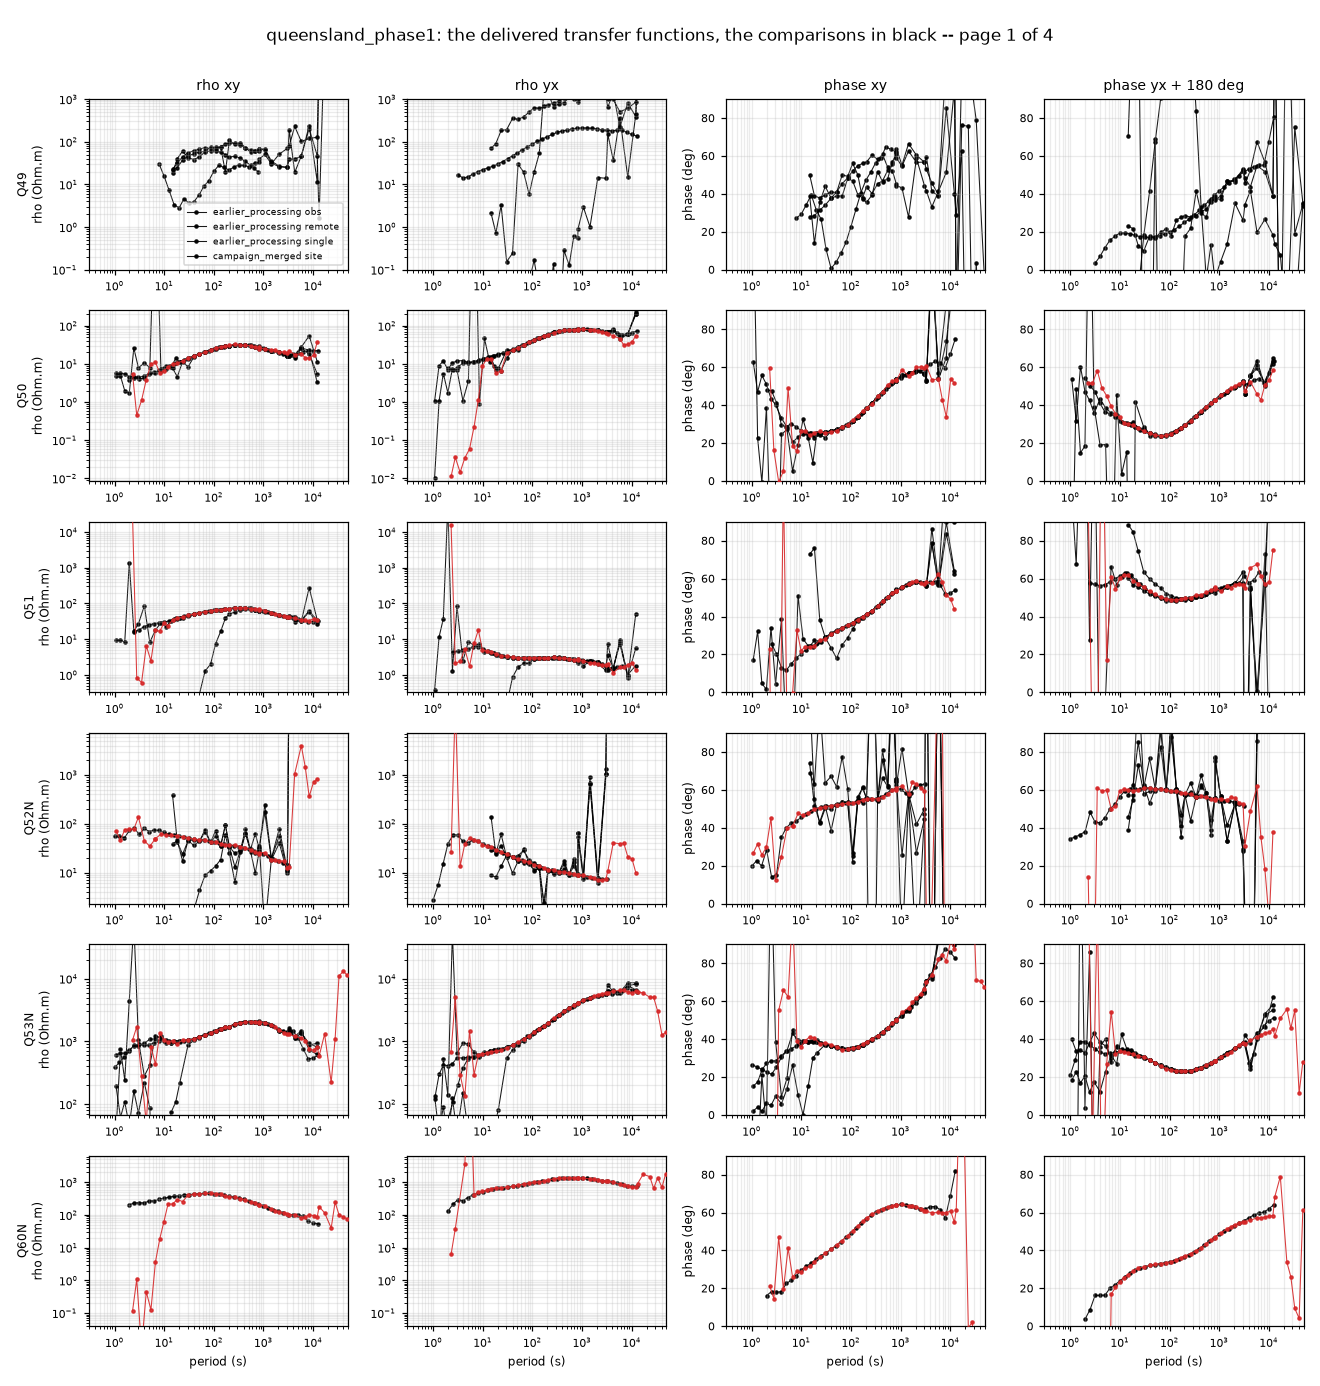


   FINAL_MANIFEST.csv       E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\FINAL_MANIFEST.csv
   PRODUCTS_OF_RECORD.csv   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\PRODUCTS_OF_RECORD.csv
   READINGS.csv             E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\READINGS.csv
   SPLICE.csv               E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\survey\SPLICE.csv

the manifest, the first ten rows
site   role component   kind  bytes                                                           sha256
 Q50  final                   24427 427375c58636368f12410bd0934de2c8757af96930cb1f562a4cb99edd51f1dd
 Q50 source        xy  stack  24847 507fae236675e8ae856ad9db7cba93a8de2c58dd3b0635efa058e6d0e6c3569d
 Q50 source        yx single  24135 85cd9a190798ade0c9f4f68ea639c59bd0057eec8f5c6418d27539e7585692fe
 Q51  final                   24604 fe2b9c0cc6b19d92c8ba0669ab7bf2d907c759602c27aa7ad56f196dd6cd1b8f
 Q51 source        xy 

In [12]:
pages, index, index_path = FIG.final_gallery(
    sorted(FINAL_TF), FINAL_TF, OUT, stem="gallery_final", per_page=int(PER_PAGE),
    period_range=tuple(PERIOD_RANGE), comparisons=COMPS,
    title="%s: the delivered transfer functions, the comparisons in black" % sv.cfg["name"])
WRITTEN += list(pages) + [index_path]
print("%d gallery page(s), %d curve(s) drawn" % (len(pages), len(index)))
if len(pages):
    display(Image(filename=str(pages[0])))

if RESAMPLE:
    for site, p in sorted(DELIVERED.items()):
        r = FN.resample(p, final_dir(site) / ("%s_resampled.edi" % site))
        WRITTEN.append(r["path"])
    print("%d file(s) also written on the ten-per-decade grid, beside the delivered file and never in "
          "place of it" % len(DELIVERED))

REC_OUT = FN.write_record(OUT, RECORD, READINGS, MERGES + TIPPER_ONLY, splice=SPLICE)
WRITTEN += list(REC_OUT["written"].values())
MAN = REC_OUT["manifest"]
print()
for name, p in sorted(REC_OUT["written"].items()):
    print("   %-24s %s" % (name, p))
print()
print("the manifest, the first ten rows")
print(MAN.head(10)[["site", "role", "component", "kind", "bytes", "sha256"]].to_string(index=False))

want = sorted({r.site for r in RECORD.itertuples() if r.product != "none"})
no_file = [s for s in want if s not in DELIVERED or not Path(DELIVERED[s]).exists()]
no_panel = [s for s in want if s not in set(index.site)] if len(index) else list(want)
no_man = [s for s in want if s not in set(MAN[MAN.role == "final"].site)]
if not want:
    print("VERDICT: UNJUDGED -- no site has a product of record, so no final was written and none was drawn")
elif no_file or no_panel or no_man:
    print("VERDICT: FAIL -- of the %d site(s) with a product of record, %d have no delivered file (%s), %d "
          "have no gallery panel (%s) and %d have no manifest row (%s)"
          % (len(want), len(no_file), " ".join(no_file) or "none", len(no_panel),
             " ".join(no_panel) or "none", len(no_man), " ".join(no_man) or "none"))
else:
    print("VERDICT: PASS -- all %d site(s) with a product of record carry a delivered file, a gallery panel "
          "and a manifest row; %d file(s) in the manifest with their sha256, %d of them delivered and %d "
          "the products they came from"
          % (len(want), len(MAN), int((MAN.role == "final").sum()), int((MAN.role == "source").sum())))


## 9. What was written

In [13]:
rows = []
for p in list(WRITTEN) + [q for s in sorted(DELIVERED) for q in
                          (Path(DELIVERED[s]), Path(DELIVERED[s]).with_suffix(".xml"))]:
    p = Path(p)
    if p.exists():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d files, %.1f MB, in %.1f minutes" % (len(files), files.kb.sum() / 1024, (time.time() - T0) / 60))
print(files.head(80).to_string(index=False))
if len(files) > 80:
    print("   ... and %d more" % (len(files) - 80))


64 files, 11.3 MB, in 1.4 minutes
                                                                                            file    kb
                     E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\final\Q49.edi  16.8
               E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\final\Q49_final.png 408.6
                     E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\final\Q50.edi  23.9
               E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\final\Q50_final.png 431.5
              E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\final\Q50_halves.png 119.3
                     E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q51\final\Q51.edi  24.0
               E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q51\final\Q51_final.png 504.3
                   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q52N\final\Q52N.edi  28.6
             E:\MT_Timeseries_DATA\MT_A